# Geometry + ellipse physics from input.ctl

Este ejemplo crea la geometría de falla desde `input.ctl` y luego aplica el modelo elíptico de 7 parámetros.

Salida:
- resumen de geometría base y rigidez por subfalla,
- mapeo elíptico (rupture times + slip físico),
- cálculo de momento total $M_0$ y magnitud $M_w$,
- vista en planta (x-y) y sección x-z.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError('No se encontro PROJECT_ROOT con carpeta kdellipspy.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
KIN_ROOT = PROJECT_ROOT / 'Kinematic_inversion'
INPUT_CTL = KIN_ROOT / 'input.ctl'
AXITRA_DIR = PROJECT_ROOT / 'kdellipspy' / 'AXITRA2024'

if not INPUT_CTL.exists():
    raise FileNotFoundError(f'No se encontro input.ctl en {INPUT_CTL}')
if not AXITRA_DIR.exists():
    raise FileNotFoundError(f'No se encontro AXITRA2024 en {AXITRA_DIR}')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from kdellipspy.forward_model import AxitraForwardModel

# Compatibilidad con celdas existentes
root = KIN_ROOT
input_ctl = INPUT_CTL
axitra_dir = AXITRA_DIR

In [5]:
input_ctl = root / 'input.ctl'
axitra_dir = root / 'AXITRA2024'

fm = AxitraForwardModel(str(input_ctl), axitra_dir=str(axitra_dir))
cfg = fm.cfg

geom_base = fm.build_geometry()
midpoint_model = np.array([
    0.5 * (float(p.min_val) + float(p.max_val))
    for p in cfg.inversion_params.parameters
], dtype=float)

if midpoint_model.size != 7:
    raise ValueError(f'Se esperaban 7 parametros, pero hay {midpoint_model.size}.')

geom = fm.build_geometry_with_ellipse_slip(midpoint_model)
m0_total, mw_total = fm.estimate_total_moment_and_mw(midpoint_model, geometry=geom)

mu_values = np.array([sf.mu_pa for sf in geom_base.subfaults], dtype=float)
area_values = np.array([sf.area_m2 for sf in geom_base.subfaults], dtype=float)

print('Input:', input_ctl)
print(f'Fault size [m]: Lx={geom_base.length_strike_m:.1f}, Ly={geom_base.length_dip_m:.1f}')
print(f'Subfault grid: {geom_base.nx} x {geom_base.ny} = {geom_base.nsubfaults}')
print(f'Strike/Dip [deg]: {geom_base.strike_deg:.1f}/{geom_base.dip_deg:.1f}')
print(f'Source depth [km]: {geom_base.source_depth_m/1000.0:.2f}')
print(f'Area subfault [m2]: min={area_values.min():.3e}, max={area_values.max():.3e}')
print(f'Rigidity mu [Pa]: min={mu_values.min():.3e}, max={mu_values.max():.3e}')
print(f'Rupture velocity (model) [km/s]: {geom.rupture_velocity_km_s:.3f}')
print(f'M0 total [N.m]: {m0_total:.6e}')
print(f'Mw total: {mw_total:.4f}')

Input: /home/alex/elliptical-rupture-updated/Kinematic_inversion/input.ctl
Fault size [m]: Lx=40000.0, Ly=40000.0
Subfault grid: 10 x 10 = 100
Strike/Dip [deg]: 72.0/47.0
Source depth [km]: 75.00
Area subfault [m2]: min=1.600e+07, max=1.600e+07
Rigidity mu [Pa]: min=7.607e+10, max=7.768e+10
Rupture velocity (model) [km/s]: 2.000
M0 total [N.m]: 1.562353e+19
Mw total: 6.7292


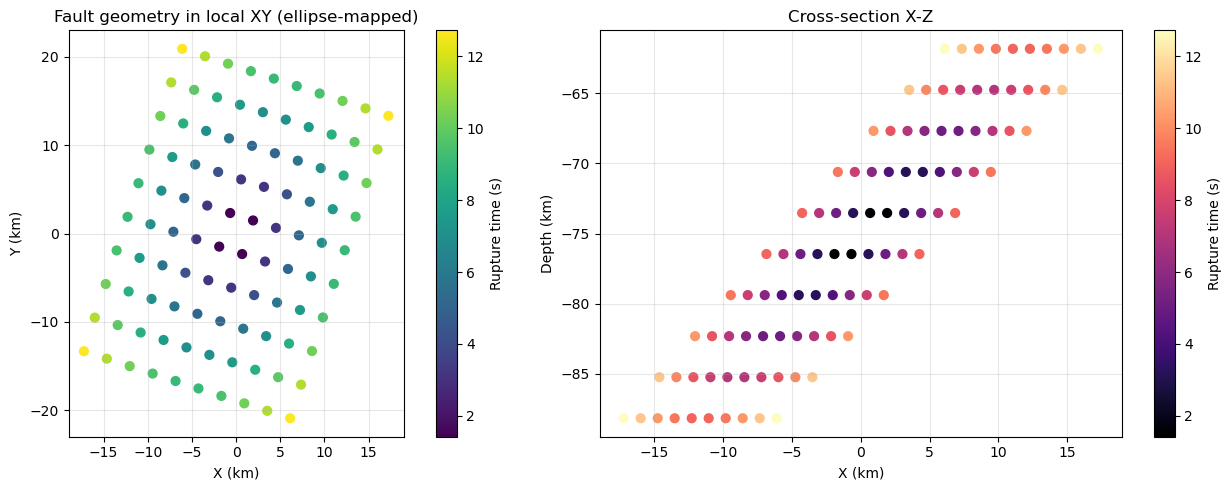

In [6]:
x = np.array([s.x_m for s in geom.subfaults]) / 1000.0
y = np.array([s.y_m for s in geom.subfaults]) / 1000.0
z = np.array([s.z_m for s in geom.subfaults]) / 1000.0
tr = np.array([s.rupture_time_s for s in geom.subfaults])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Planta XY
sc1 = ax[0].scatter(x, y, c=tr, cmap='viridis', s=40)
ax[0].set_title('Fault geometry in local XY (ellipse-mapped)')
ax[0].set_xlabel('X (km)')
ax[0].set_ylabel('Y (km)')
ax[0].set_aspect('equal')
ax[0].grid(True, alpha=0.3)
fig.colorbar(sc1, ax=ax[0], label='Rupture time (s)')

# Seccion XZ
sc2 = ax[1].scatter(x, -z, c=tr, cmap='magma', s=40)
ax[1].set_title('Cross-section X-Z')
ax[1].set_xlabel('X (km)')
ax[1].set_ylabel('Depth (km)')
ax[1].grid(True, alpha=0.3)
fig.colorbar(sc2, ax=ax[1], label='Rupture time (s)')

plt.tight_layout()
plt.show()

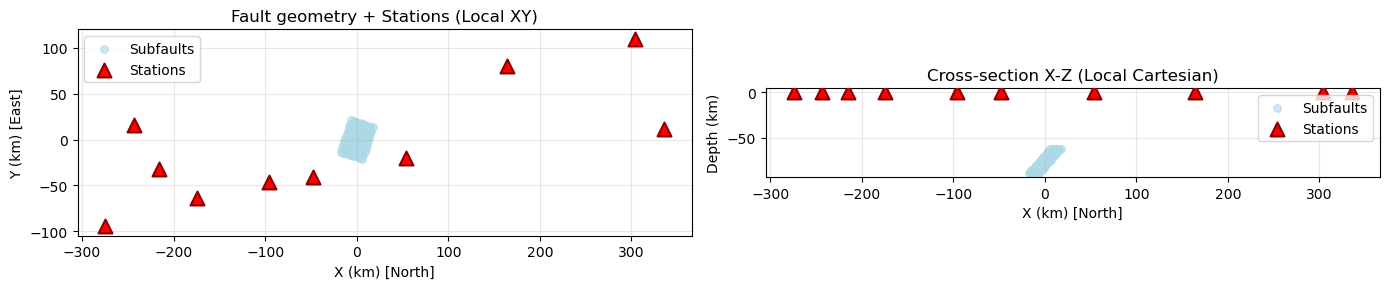

Stations in Cartesian (local coords):
  1: AC01   X=  54.163 km  Y= -20.087 km  Z= 0.000 km
  2: A30C   X= -48.273 km  Y= -40.729 km  Z= 0.000 km
  3: A18C   X= -96.347 km  Y= -46.650 km  Z= 0.000 km
  4: GO02   X= 164.204 km  Y=  80.289 km  Z= 0.000 km
  5: AC04   X=-174.433 km  Y= -63.810 km  Z= 0.000 km
  6: A10C   X=-215.497 km  Y= -32.183 km  Z= 0.000 km
  7: AC05   X=-243.263 km  Y=  15.460 km  Z= 0.000 km
  8: A32C   X=-274.466 km  Y= -94.791 km  Z= 0.000 km
  9: PB19   X= 303.481 km  Y= 110.129 km  Z= 0.000 km
  10: A24F   X= 335.603 km  Y=  10.998 km  Z= 0.000 km


In [11]:
# Plot with stations in Cartesian coordinates
stations_cart = fm.stations_array(latlon=False)  # [nstations x 4]: [index, x, y, z]
st_x = stations_cart[:, 1] / 1000.0  # Convert to km
st_y = stations_cart[:, 2] / 1000.0
st_z = stations_cart[:, 3] / 1000.0

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Planta XY with subfaults and stations
ax[0].scatter(x, y, c='lightblue', s=30, alpha=0.6, label='Subfaults')
ax[0].scatter(st_x, st_y, c='red', s=100, marker='^', edgecolors='darkred', 
              linewidth=1.5, label='Stations', zorder=5)
ax[0].set_title('Fault geometry + Stations (Local XY)')
ax[0].set_xlabel('X (km) [North]')
ax[0].set_ylabel('Y (km) [East]')
ax[0].set_aspect('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Seccion XZ with subfaults and stations
ax[1].scatter(x, -z, c='lightblue', s=30, alpha=0.6, label='Subfaults')
ax[1].scatter(st_x, -st_z, c='red', s=100, marker='^', edgecolors='darkred',
              linewidth=1.5, label='Stations', zorder=5)
ax[1].set_title('Cross-section X-Z (Local Cartesian)')
ax[1].set_xlabel('X (km) [North]')
ax[1].set_ylabel('Depth (km)')
ax[1].set_aspect('equal')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Stations in Cartesian (local coords):")
for i, st in enumerate(fm.cfg.stations.stations, start=1):
    print(f"  {i}: {st.name:6s} X={st_x[i-1]:8.3f} km  Y={st_y[i-1]:8.3f} km  Z={st_z[i-1]:6.3f} km")


## Forward model with AXITRA wrapper (Cartesian workflow)

Orden recomendado del flujo actualizado:
1. Parsear `input.ctl` y construir geometría base invariante.
2. Aplicar el modelo elíptico de 7 parámetros (incluye $\mu(z)$ y área por subfalla).
3. Calcular $M_0$ y $M_w$ para ese modelo.
4. Pasar estaciones y fuentes al sistema cartesiano local (`latlon=False`).
5. Calcular funciones de Green (`moment.green`).
6. Ejecutar convolución (`moment.conv`).

Nota: en este ejemplo usamos sistema local x-y-z para mantener consistencia geométrica.

In [ ]:
from src.forward_model import AxitraForwardModel

# Step 1: cargar parser/modelo de alto nivel
fm = AxitraForwardModel(str(input_ctl), axitra_dir=str(root / 'AXITRA2024'))

# Step 2: construir geometria/falla con un Vr candidato
geom_fw = fm.build_geometry(rupture_velocity_km_s=2.486)

# Step 3: construir instancia Axitra en cartesiano local
# latlon=False => estaciones convertidas a x/y locales y sources en x/y locales
ap = fm.build_axitra(
    geom_fw,
    fmax=None,      # por defecto: 1/Delta / 2 desde input.ctl
    duration=None,  # por defecto: t2 - t1
    latlon=False,
    xl=0.0,
    freesurface=True,
    ikmax=100000,
    aw=2.0,
)

print('Subfaults:', geom_fw.nsubfaults)
print('AXITRA sources:', geom_fw.nsources)
print('MT enabled:', geom_fw.mt_enabled)
print('Cartesian mode (latlon=False):', ap.latlon == False)
print('Axitra id:', ap.id, 'nfreq:', ap.nfreq, 'nsource:', ap.nsource)

Subfaults: 25
AXITRA sources: 150
MT enabled: True
Cartesian mode (latlon=False): True
Axitra id: 797 nfreq: 256 nsource: 150


 running axitra Moment Version 20212403.1
 running openMp on            6  threads


  with          150 source(s) and            7 receiver(s) and            2 layer(s)
 ................. with a free surface at depth Z=0
 distance unit is detected as meter
freq   256/  256 iter=      279 Done
/home/alex/elliptical-rupture-updated/Kinematic_inversion/AXITRA2024/axitra ran sucessfully
 Moment (Nm):   1520000000000000.0     
 Moment (Dyne.cm):   1.5200000000000000E+022
 Moment (Nm):   29600000000000000.     
 Moment (Dyne.cm):   2.9599999999999998E+023
 Moment (Nm):   18900000000000000.     
 Moment (Dyne.cm):   1.8900000000000000E+023
 Moment (Nm):   5.1900000000000000E+017
 Moment (Dyne.cm):   5.1899999999999995E+024
 Moment (Nm):   1.0300000000000000E+017
 Moment (Dyne.cm):   1.0300000000000000E+024
 Moment (Nm):   5.1400000000000000E+017
 Moment (Dyne.cm):   5.1400000000000005E+024
 Moment (Nm):   1520000000000000.0     
 Moment (Dyne.cm):   1.5200000000000000E+022
 Moment (Nm):   29600000000000000.     
 Moment (Dyne.cm):   2.9599999999999998E+023
 Moment (Nm):   18

 running openMp on            6  threads


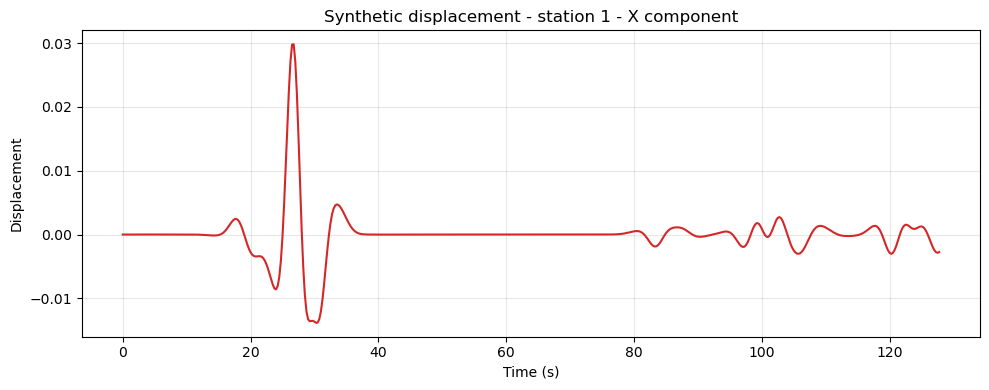

In [ ]:
# 1) Green functions (puede tardar dependiendo de la malla y frecuencia)
ap = fm.green(ap, quiet=True)

# 2) Convolution con source_type=1 (Ricker), usando hist generado desde la geometria
t, sx, sy, sz = fm.conv(
    ap,
    geom_fw,
    source_type=1,
    t0=float(fm.cfg.ellipse.t0),
    quiet=True,
  )

print('Shapes:', t.shape, sx.shape, sy.shape, sz.shape)

# Quicklook: componente X para la primera estacion
plt.figure(figsize=(10, 4))
plt.plot(t, sx[0, :], color='tab:red', lw=1.5)
plt.title('Synthetic displacement - station 1 - X component')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

try:
    ap.clean()
except Exception:
    pass

In [ ]:
print('npts:', t.size)
print('dt  :', float(t[1] - t[0]) if t.size > 1 else np.nan)
print('sx shape:', sx.shape, '(nstations, npts)')

512